## Atividade 1
Prof Levy Boccato

Aluno 1: Pedro Henrique Pinheiro Linhares - 175807

Aluno 2: Rafael Campideli Hoyos - 175100

## Resumo
Esta atividade consiste em utilizar o modelo de regressão linear para realizar previsões em uma série temporal que apresenta três momentos, sendo um deles muito diferente dos outros dois. Este momento corresponde à pandemia de covid-19, que afetou o mundo inteiro de forma devastadora. Uma das formas de controlar o alastramento desta doença foi através da quarentena, que consistiu em manter todas as pessoas isoladas em suas casas, permitindo a saída apenas para trabalhadores essenciais, como profissionais de saúde.

Nesta realidade que durou os anos de 2020 e 2021, aproximadamente, marcam um acontecimento inédito na série temporal amostrada. Neste momento, houve uma queda abrupta no número dos vôos, que se manteve por mais de um ano, e que se modificou após a adoção de algumas medidas de flexibilização da quarentena.

Tendo este contexto, foi proposto pela atividade o uso do modelo de reressão linear para realizar tais previsões. Para isto, nossa dupla utilizou o modelo de regressão linear do scikit-learning para realizar as predições. Além disto, as métricas de qualidade do modelo foram extraídas da mesma biblioteca de acordo com o que nos foi pedido na atividade.

Por se tratar de uma série temporal, tivemos que utilizar a estratégia do uso de lag, como proposto na atividade, para realizar as predições, pois utilizar toda a série temporal para isto seria muito custoso computacionalmente, visto que iria gerar um vetor de pesos do tamanho da série temporal. Além disso, informações muito antigas tendem a não interferir de forma significativa na predição. Para isto, foram criadas matrizes com valores atrasados cujo tamanho dependia do valor do atraso.

Outra estratégia adotada foi o uso de duas normalizações diferentes para saber como elas iriam influenciar na previsão do modelo. As normalizações adotadas foram z-norma e minmax.

Por fim, para o treinamento e validação do modelo, foi adotada estratégia do holdout. Desta forma, utilizamos os anos de 2018 e 2019 para servirem de validação para o treinamento no item b. Já para o item c, foram utilizados os anos de 2020 e 2021 como propostos pelo enunciado.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
import os
from google.colab import drive

In [ ]:
def data(ano, mes):
    ano_mes = []
    for i, j in zip(ano, mes):
        ano_str = str(i)
        mes_str = str(j)
        ano_mes.append(mes_str+'/'+ano_str)
    return ano_mes

In [ ]:
# Monta o Drive
drive.mount('/content/drive')

# Define o caminho onde o arquivo tá guardado
caminho = '/content/drive/MyDrive/IA048/Atividade1/air traffic.csv'

df = pd.read_csv(caminho)

mes_ano = data(df["Year"], df["Month"])
voos = df["Flt"].str.replace(",", "").astype(int).to_numpy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


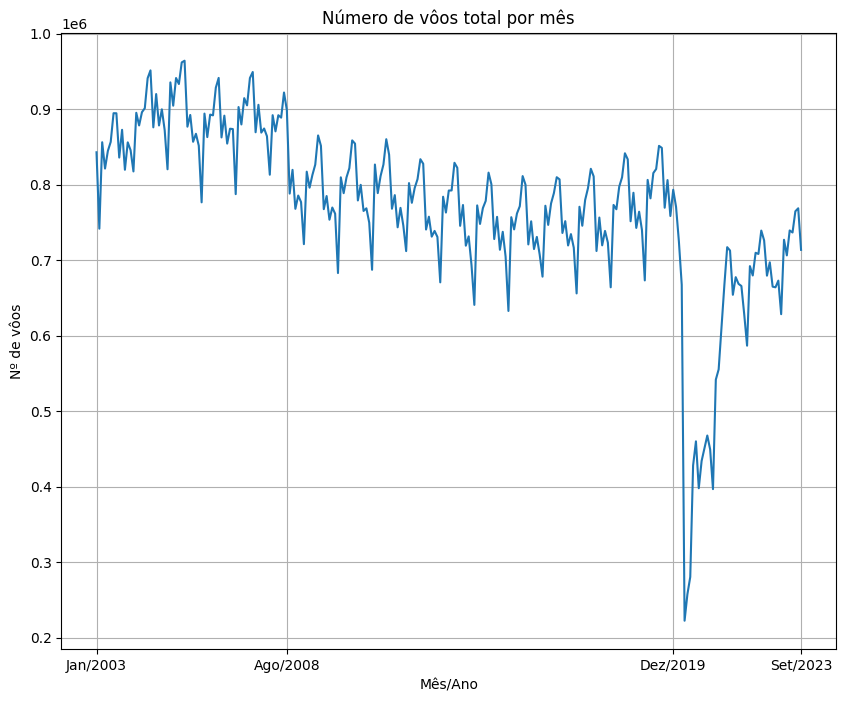

In [ ]:
voos_int = df['Flt'].str.replace(',', '').astype(int)

posicoes = [0, 67, 203, 248]
rotulos = ["Jan/2003", "Ago/2008", "Dez/2019", "Set/2023"]

# Exibição de série temporal
plt.figure(figsize=(10, 8))

plt.plot(df.index,
         voos_int
         )

plt.xticks(ticks=posicoes, labels=rotulos)
plt.grid()
plt.title("Número de vôos total por mês")
plt.xlabel("Mês/Ano")
plt.ylabel("Nº de vôos")

plt.show()

# Item a
A partir da série temporal é possível observar 3 claras tendências ao longo dos anos.
- **De Jan/2003 até Ago/2008**: Houve a crise imobiliária dos EUA, que se espalhou de forma global. Esta foi responsável por causar a falência de muitas pessoas. Desta forma, houve uma queda na tendência de vôos nos anos seguintes.
- **De Set/2008 até Dez/2019**: Após a crise, muitos estadunidenses não conseguiram se recuperar, mantendo a tendência de vôos anual em baixa quando comparada com o período anterior. Além disso, até 2015, aproximadamente, houve a crise do euro, o que acarretou uma tendência de queda durante a primeira metade deste período, o que só foi revertido a partir do acordo de recuperação econômica da Grécia. Após isso, houve uma tendência de aumento nos anos subsequentes.
- **De Jan/2020 até Set/2023**: Nos primeiros meses de 2020 começaram a aparecer os primeiros casos de covid-19, ocasionando o decreto de um período de quarentena global, que foi responsável por paralisar qualquer tipo de mobilidade humana pelos meses seguintes. Isto só começou a ser revertido após as medidas de flexibilização da quarentena, que veio junto com o início das vacinações contra o vírus. Porém, mesmo após o fim da quarentena, a tendência de vôos não foi recuperado, visto que este período ocasionou uma crise econômica global, já que o comércio foi paralisado por todo o período.

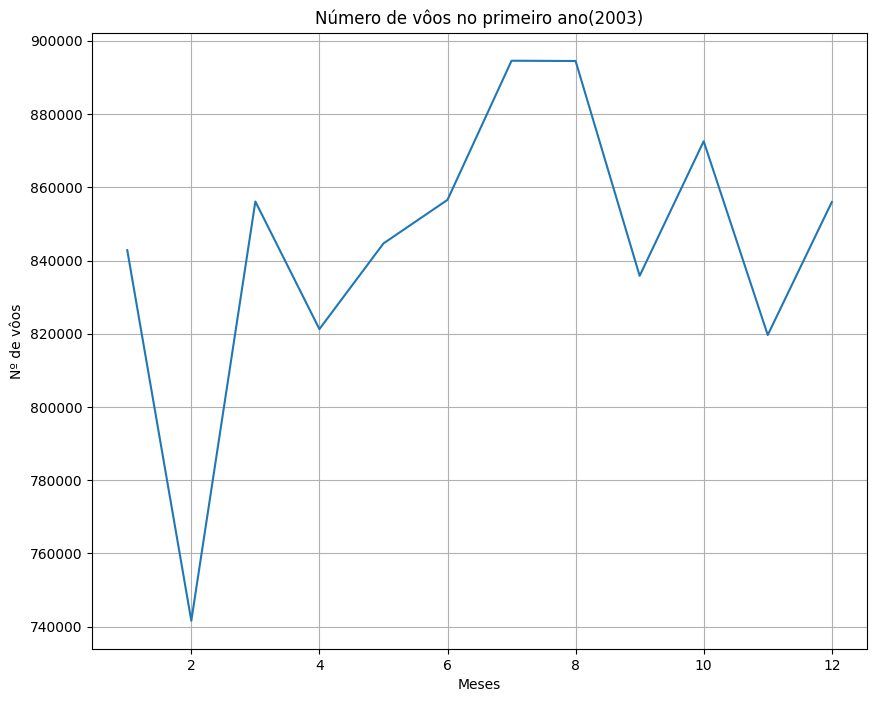

In [ ]:
# Exibição de série temporal
plt.figure(figsize=(10, 8))

plt.plot(df.index[0:12]+1,
         voos_int[0:12]
         )


plt.grid()
plt.title("Número de vôos no primeiro ano(2003)")
plt.xlabel("Meses")
plt.ylabel("Nº de vôos")

plt.show()

In [ ]:
def geracao_k(dados, k):
    '''Cria o dataframe com lag de k que será usado para alimentar o modelo'''

    matriz = pd.DataFrame({"y": dados})

    for i in range(1, k + 1):
        matriz[f'x{i}'] = matriz["y"].shift(i)
    matriz_limpa = matriz.dropna().reset_index(drop=True)

    X = matriz_limpa[[f"x{i}" for i in range(1, k + 1)]]
    y = matriz_limpa["y"]
    return X, y

O K ideal encontrado na validação foi K = 14


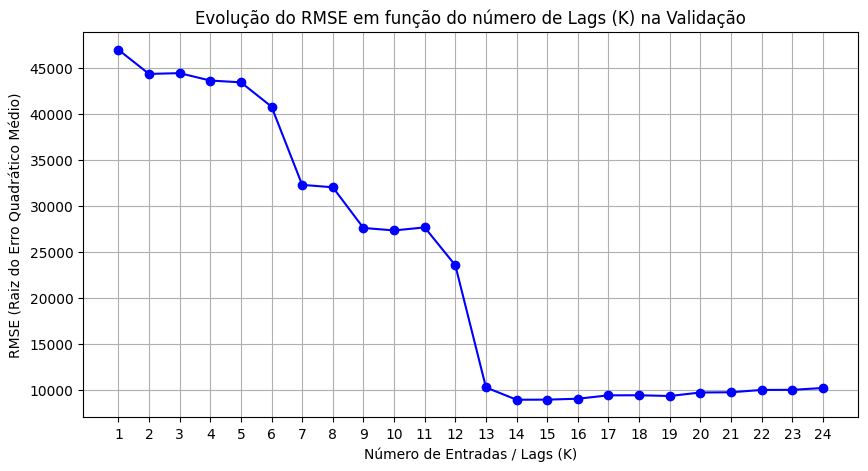

In [ ]:
# Variação de K de 1 a 24 com validação
rmses_validacao = []
ks = list(range(1, 25))

for k in ks:
    # Gerar a matriz de lags
    X, y = geracao_k(voos, k)

    # Separação do treinamento
    anos_y = df["Year"].to_numpy()[k:]
    meses_y = df["Month"].to_numpy()[k:]

    # Treinamento: 2003-2017
    idx_treino = anos_y <= 2017

    # Validação: 2018-2019
    idx_validacao = (anos_y >= 2018) & (anos_y <= 2019)

    X_treino = X[idx_treino]
    y_treino = y[idx_treino]

    X_validacao = X[idx_validacao]
    y_validacao = y[idx_validacao]

    # Treinamento do modelo autoregressivo
    modelo = LinearRegression()
    modelo.fit(X_treino, y_treino)

    # Validação
    previsoes = modelo.predict(X_validacao)

    rmse = root_mean_squared_error(
        y_validacao,
        previsoes
    )

    rmses_validacao.append(rmse)

# Plotagem do gráfico de RMSE
plt.figure(figsize=(10, 5))
plt.plot(list(ks), rmses_validacao, marker="o", color="b", linestyle="-")
plt.title("Evolução do RMSE em função do número de Lags (K) na Validação")
plt.xlabel("Número de Entradas / Lags (K)")
plt.ylabel("RMSE (Raiz do Erro Quadrático Médio)")
plt.xticks(list(ks))
plt.grid(True)

# Descoberta do melhor K
melhor_k = list(ks)[np.argmin(rmses_validacao)]
print(f"O K ideal encontrado na validação foi K = {melhor_k}")

## Item b1
Este gráfico evidencia três platôs.
1. 1<=K<=6: Neste intervalo o modelo está prevendo muito mal, tendo em vista os RMSE médios de cada ponto. Isto pode ter relação com o fato de que menos da metade do ano está sendo usado. E como durante o ano existem muitas flutuações, a tendência anual não é levada em consideração.
2. 7<=K<=12: Neste intervalo já é possível obter um platô mediano, com valores para RMSE melhores em média. Uma possível justificativa é o fato de que o modelo está aprendendo com muito mais dados que anteriormente. Com isto, é possível que um lag de até um ano ainda não é bom o suficiente.
3. 13<=K<=24: Este intervalo é o melhor platô de todos, permitindo observar que adicionar mais de um ano de lag na série temporal é muito bom para reduzir o RMSE. Porém, a inferência de que aumentar o lag indiscriminadamente reduz o RMSE é incorreta, pelo que pode ser visto no gráfico.

Desta forma, conjecturamos que no caso 1 o modelo fica muito frágil a variações, pois ele não teve disponível um intervalo suficientemente satisfatório para prever flutuações. Já o caso 3 mostra que o modelo com pelo menos 13 meses de lag apresenta uma melhor previsão da série temporal por conta de ter tido dados suficientes para formar uma boa previsão, porém, aumentar este lag faz com que o modelo faça previsões levemente piores, provavelmente por conta de que os dados muito atrasados não possuem tanta relação com os dados que serão previstos, se tornando apenas ruído. Por fim, este excesso de pontos faz com que o modelo fique excessivamente ajustado a este período fornecido. Desta forma, dados novos não terão tanta qualidade na previsão.

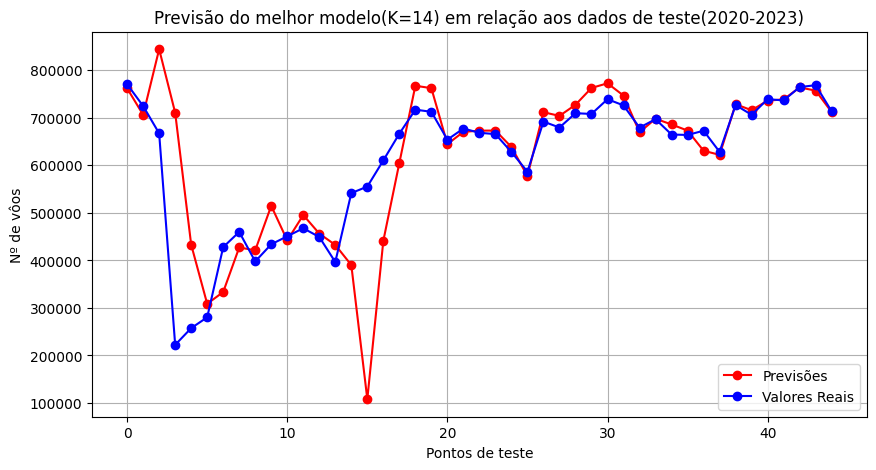

In [ ]:
# Geração dos valores de previsão do teste com K = 14
X, y = geracao_k(voos, melhor_k)

# Separação do teste
anos_y = df["Year"].to_numpy()[melhor_k:]
meses_y = df["Month"].to_numpy()[melhor_k:]

# Treinamento: 2003-2017
idx_treino = anos_y <= 2017

# Teste: 2020-2023
idx_teste = anos_y >= 2020

X_treino = X[idx_treino]
y_treino = y[idx_treino]

X_teste = X[idx_teste]
y_teste = y[idx_teste]

# Treinamento do modelo autoregressivo de k = 14
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Validação
previsoes_teste = modelo.predict(X_teste)

# Plot da série predita em comparação com a série teste
plt.figure(figsize=(10, 5))

plt.plot(range(len(previsoes_teste)),list(previsoes_teste), label="Previsões", marker="o", color="r")

plt.plot(range(len(voos[204:])),list(voos[204:]), label="Valores Reais", marker="o", color="b")

plt.legend(loc="lower right", frameon=True, fontsize=10)

plt.title("Valores Reais vs Previsões")

plt.title("Previsão do melhor modelo(K=14) em relação aos dados de teste(2020-2023)")
plt.xlabel("Pontos de teste")
plt.ylabel("Nº de vôos")
plt.grid(True)

In [ ]:
# Cálculo de métricas do modelo em relação aos dados de teste indo de 2020 até 2023

# RMSE da previsão com o melhor K
rmse_teste = root_mean_squared_error(
        y_teste,
        previsoes_teste
    )
print(f"O RMSE do modelo com o melhor K é {rmse_teste:.4f}.\n")

# MAPE da previsão com o melhor K
mape = mean_absolute_percentage_error(y_teste, previsoes_teste)
print(f"O MAPE do modelo com o melhor K é {mape:.4f}.\n")

# R^2 da previsão com o melhor K
r2 = r2_score(y_teste, previsoes_teste)
print(f"O R^2 do modelo com o melhor K é {r2:.4f}.")

O RMSE do modelo com o melhor K é 114566.1933.

O MAPE do modelo com o melhor K é 0.1353.

O R^2 do modelo com o melhor K é 0.3582.


## Item b2
Analisando o gráfico do predito para os dados do teste em função dos dados reais, é possível concluir que o modelo foi muito ineficiente para predizer os valores fora da normalidade do período, no caso, a pandemia. Após esse período, o modelo voltou a predizer de forma muito mais coerente.

Isto faz sentido quando se leva em consideração que todo o modelo foi treinado e validado com dados de um período de normalidade, em que o período da série estava estabilizado em 12 meses.

Analisando de forma mais detalhista, é possível observar que os dados previstos estão inicialmente seguindo a tendência em que eles foram treinados para seguir.Porém, ao lidar com a nova realidade dos dados pandêmicos, ele começa bem nos dois primeiros meses, antes da quarentena, e logo se observa um erro absurdo, pois o terceiro mês já trouxe um padrão em que o modelo não estava treinado para prever. Assim, ele passa os anos seguintes errando absurdamente, até que o contexto global volte à realidade em que ele estava acostumado.

Note que a recuperação da normalidade ocorre de forma muito rápida. Isto ocorre por que provavelmente o modelo considera que os meses recentes são muito influentes na tomada de decisão.

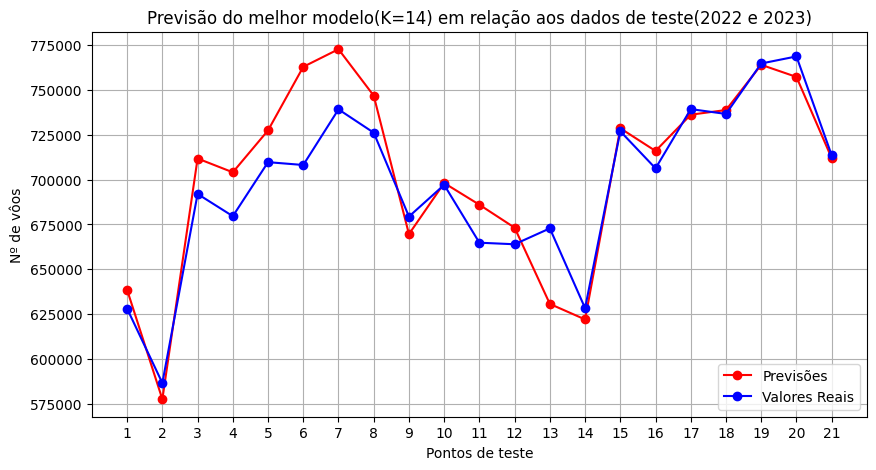

In [ ]:
# Plot da série predita em comparação com a série teste para os anod 2022 e 2023
plt.figure(figsize=(10, 5))

plt.plot(range(len(previsoes_teste[-21:])),list(previsoes_teste[-21:]), label="Previsões", marker="o", color="r")

plt.plot(range(len(voos[228:])),list(voos[228:]), label="Valores Reais", marker="o", color="b")

plt.legend(loc="lower right", frameon=True, fontsize=10)

plt.xticks(ticks=range(0, 21), labels=range(1, 22))

plt.title("Previsão do melhor modelo(K=14) em relação aos dados de teste(2022 e 2023)")
plt.xlabel("Pontos de teste")
plt.ylabel("Nº de vôos")
plt.grid(True)

In [ ]:
# Cálculo de métricas do modelo em relação aos dados de teste indo de 2022 e 2023

# RMSE da previsão com o melhor K
rmse_teste = root_mean_squared_error(
        y_teste[-21:],
        previsoes_teste[-21:]
    )
print(f"O RMSE do modelo com o melhor K é {rmse_teste:.4f}.\n")

# MAPE da previsão com o melhor K
mape = mean_absolute_percentage_error(y_teste[-21:], previsoes_teste[-21:])
print(f"O MAPE do modelo com o melhor K é {mape:.4f}.\n")

# R^2 da previsão com o melhor K
r2 = r2_score(y_teste[-21:], previsoes_teste[-21:])
print(f"O R^2 do modelo com o melhor K é {r2:.4f}.")

O RMSE do modelo com o melhor K é 20377.0329.

O MAPE do modelo com o melhor K é 0.0213.

O R^2 do modelo com o melhor K é 0.7935.


## Continuação do item b2 com o b3
Tomando agora os anos de 2022 e 2023 como referência, é possível observar que o modelo previu com muito mais qualidade os dados de teste. Isso é notável ao se comparar os dados reais com os dados previstos no gráfico.

Além disso, ao se comparar as métricas de performance, conseguimos tirar conclusões bem mais embasadas. Quando se considerou todo o período de 2020 até 2023, tivemos um R^2 de 0.3582, já para apenas o período de 2022 e 2023 tivemos um R^2 de 0.7935. Esta métrica foca na explicabilidade do modelo. Sabendo que, quanto mais próximo de 1, mais o modelo explica a realidade e quanto mais próximo de 0, menos o modelo explica a realidade. Desta forma, o segundo valor está evidenciando que o modelo está muito mais fiel à realidade quando se considera o período de normalidade global pós-pandêmico. E que ele está errando muito para a realidade pandêmica. O mesmo ocorre para o RMSE e para o MAPE, que corroboram para a mesma conclusão.

## Adição de normalização dos dados
A partir daqui serão adicionados diferentes tipos de normalização para analisar como o modelo se comporta a partir desta adição desta técnica.

Para realizar este estudo iremos utilizar o método mais comum Z-Score e um outro método não tão utilizado, o MinMax.

In [ ]:
def normalizar_serie(voos, anos, metodo):
    """
    Normaliza a série temporal utilizando SOMENTE os dados
    do período de treinmaento (2003-2017)
    """

    dados_treino = voos[anos <= 2017].reshape(-1, 1)

    if metodo == "zscore":
        scaler = StandardScaler()

    elif metodo == "minmax":
        scaler = MinMaxScaler()

    # Calcula os parâmetros SOMENTE com o treinamento(2003-2017)
    scaler.fit(dados_treino)

    # Aplica os mesmos parâmetros à série inteira
    voos_normalizados = scaler.transform(voos.reshape(-1, 1)).flatten()

    return voos_normalizados, scaler

Para o z-score, o K ideal encontrado na validação foi K = 14
Para o minmax, o K ideal encontrado na validação foi K = 14


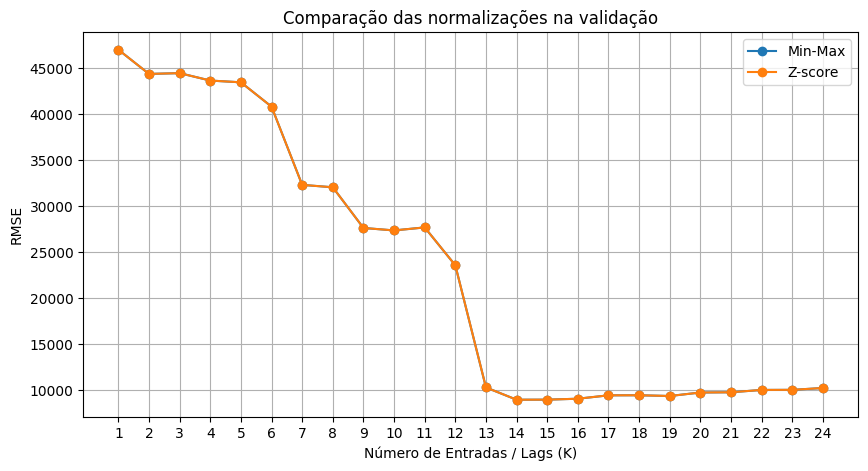

In [ ]:
# Separação de Treino (2003-2019) e Teste (2020-2023)

# Variação de K de 1 a 24 com validação

ks = list(range(1, 25))
anos = df["Year"].to_numpy()

resultados = {}

for metodo in ["zscore", "minmax"]:

    # Normalização
    voos_norm, scaler = normalizar_serie(
        voos.astype(float),
        anos,
        metodo
    )

    rmses = []
    for k in ks:
        # Gerar a matriz de lags
        X, y = geracao_k(voos_norm, k)

        # Ano correspondente ao valor que está sendo previsto
        anos_y = anos[k:]

        # Treinamento: 2003-2017
        idx_treino = anos_y <= 2017

        # Validação: 2018-2019
        idx_validacao = (
            (anos_y >= 2018) &
            (anos_y <= 2019)
        )

        X_treino = X[idx_treino]
        y_treino = y[idx_treino]

        X_validacao = X[idx_validacao]
        y_validacao = y[idx_validacao]

        # Modelo
        modelo = LinearRegression()

        modelo.fit(
            X_treino,
            y_treino
        )

        # Previsão
        previsoes = modelo.predict(X_validacao)

        # Volta para a escala original
        previsoes_originais = scaler.inverse_transform(
            previsoes.reshape(-1, 1)
        ).flatten()

        y_validacao_original = scaler.inverse_transform(
            y_validacao.to_numpy().reshape(-1, 1)
        ).flatten()

        # RMSE na escala original
        rmse = root_mean_squared_error(
            y_validacao_original,
            previsoes_originais
        )

        rmses.append(rmse)

    resultados[metodo] = rmses

# Plotagem do gráfico de RMSE
plt.figure(figsize=(10, 5))

plt.plot(ks, resultados["minmax"], marker="o", label="Min-Max")
plt.plot(ks, resultados["zscore"], marker="o", label="Z-score")


plt.xlabel("Número de Entradas / Lags (K)")
plt.ylabel("RMSE")
plt.title("Comparação das normalizações na validação")
plt.xticks(ks)
plt.grid(True)
plt.legend()

# Descoberta do melhor K
melhor_k = list(ks)[np.argmin(resultados['zscore'])]
print(f"Para o z-score, o K ideal encontrado na validação foi K = {melhor_k}")
melhor_k = list(ks)[np.argmin(resultados['minmax'])]
print(f"Para o minmax, o K ideal encontrado na validação foi K = {melhor_k}")

## Conclusão sobre normalização
A partir da investigação sobre a aplicação de diferentes técnicas de normalização dos dados, é possível concluir que, para este caso específico, não existe diferença significativa entre aplicar normalização ou não. Desta forma, mantemos para o próximo item a não aplicação da normalização.

O K ideal encontrado na validação foi K = 5


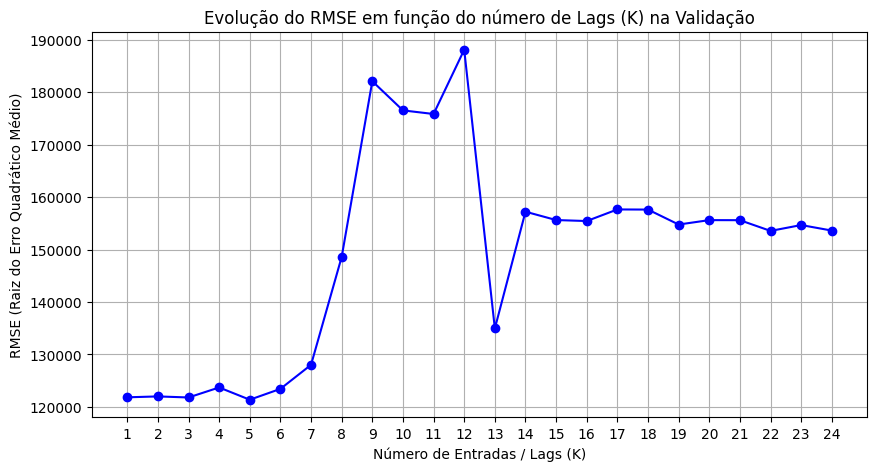

In [ ]:
# Variação de K de 1 a 24 com validação
rmses_validacao = []
ks = list(range(1, 25))
melhor_prev = []

for k in ks:
    # Gerar a matriz de lags
    X, y = geracao_k(voos, k)

    # Separação do treinamento
    anos_y = df["Year"].to_numpy()[k:]
    meses_y = df["Month"].to_numpy()[k:]

    # Treinamento: 2003-2019
    idx_treino = anos_y <= 2019

    # Validação: 2020-2021
    idx_validacao = (anos_y >= 2020) & (anos_y <= 2021)

    X_treino = X[idx_treino]
    y_treino = y[idx_treino]

    X_validacao = X[idx_validacao]
    y_validacao = y[idx_validacao]

    # Treinamento do modelo autoregressivo
    modelo = LinearRegression()
    modelo.fit(X_treino, y_treino)

    # Validação
    previsoes = modelo.predict(X_validacao)

    rmse = root_mean_squared_error(
        y_validacao,
        previsoes
    )

    rmses_validacao.append(rmse)

# Plotagem do gráfico de RMSE
plt.figure(figsize=(10, 5))
plt.plot(list(ks), rmses_validacao, marker="o", color="b", linestyle="-")
plt.title("Evolução do RMSE em função do número de Lags (K) na Validação")
plt.xlabel("Número de Entradas / Lags (K)")
plt.ylabel("RMSE (Raiz do Erro Quadrático Médio)")
plt.xticks(list(ks))
plt.grid(True)

# Descoberta do melhor K
melhor_k = list(ks)[np.argmin(rmses_validacao)]
print(f"O K ideal encontrado na validação foi K = {melhor_k}")

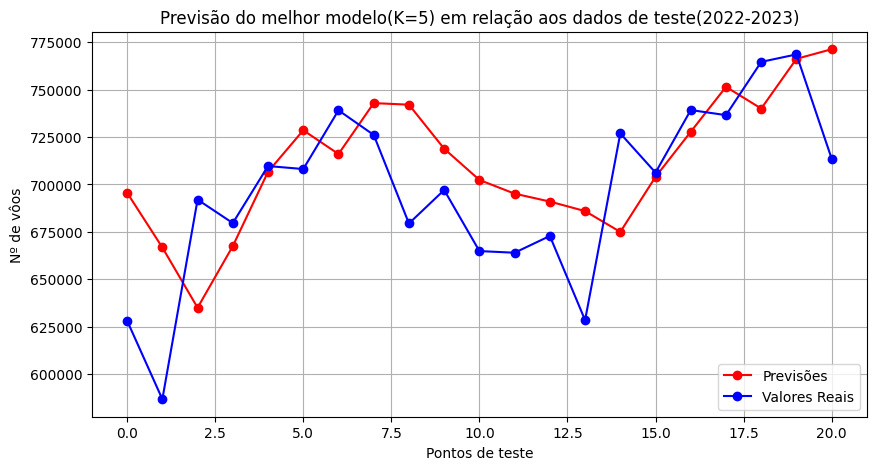

In [ ]:
# Geração dos valores de previsão do teste com K = 5
X, y = geracao_k(voos, melhor_k)

# Separação do teste
anos_y = df["Year"].to_numpy()[melhor_k:]
meses_y = df["Month"].to_numpy()[melhor_k:]

# Treinamento: 2003-2019
idx_treino = anos_y <= 2019

# Teste: 2022-2023
idx_teste = anos_y >= 2022

X_treino = X[idx_treino]
y_treino = y[idx_treino]

X_teste = X[idx_teste]
y_teste = y[idx_teste]

# Treinamento do modelo autoregressivo de k = 5
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Validação
previsoes_teste = modelo.predict(X_teste)

# Plot da série predita em comparação com a série teste
plt.figure(figsize=(10, 5))

plt.plot(range(len(previsoes_teste)),list(previsoes_teste), label="Previsões", marker="o", color="r")

plt.plot(range(len(voos[-21:])),list(voos[-21:]), label="Valores Reais", marker="o", color="b")

plt.legend(loc="lower right", frameon=True, fontsize=10)

plt.title("Valores Reais vs Previsões")

plt.title("Previsão do melhor modelo(K=5) em relação aos dados de teste(2022-2023)")
plt.xlabel("Pontos de teste")
plt.ylabel("Nº de vôos")
plt.grid(True)

In [ ]:
# Cálculo de métricas do modelo em relação aos dados de teste indo de 2020 até 2023

# RMSE da previsão com o melhor K
rmse_teste = root_mean_squared_error(
        y_teste,
        previsoes_teste
    )
print(f"O RMSE do modelo com o melhor K é {rmse_teste:.4f}.\n")

# MAPE da previsão com o melhor K
mape = mean_absolute_percentage_error(y_teste, previsoes_teste)
print(f"O MAPE do modelo com o melhor K é {mape:.4f}.\n")

# R^2 da previsão com o melhor K
r2 = r2_score(y_teste, previsoes_teste)
print(f"O R^2 do modelo com o melhor K é {r2:.4f}.")

O RMSE do modelo com o melhor K é 39682.9311.

O MAPE do modelo com o melhor K é 0.0478.

O R^2 do modelo com o melhor K é 0.2167.


## Conclusão sobre o item c
Neste item foi pedido que o conjunto de validação fosse modificado para se usar os anos de 2020 e 2021, diferenciando do que anteriormente havia sido feito, pois usamos os anos 2018 e 2019 como validação.

A partir desta mudança foi possível observar o quanto o conjunto de validação influencia na arquitetura do modelo. No caso do item b, foi utilizado um período em que a série temporal ainda estava se comportando de forma normal. O período era o mesmo para toda a mostra de 2003 até 2019, assim, temos que o conjunto de treinamento e validação estavam se comportando da mesma maneira, ou seja, existia uma certa previsibilidade.

No caso do item c, incluímos no treinamento e validação algo que pode ser considerado como uma interferência ou um ruído na série temporal. Podemos considerar que o que aconteceu em 2008 também foi algo que pode ser considerado como um ruído, porém, além de ser muito menor em comparação à quarentena, ele se perde frente ao espaço amostral fornecido ao modelo.

A mudança do conjunto de validação afetou o modelo de forma que o K ideal ficou em torno de valores muito menores, o que pode ser interpretado como o modelo se tornando mais cauteloso e mais desconfiado dos dados antigos, visto que estes dados não forneceram informação suficiente para que o modelo pudesse prever o que estaria ocorrendo no conjunto de validação.

Outra mudança foi a qualidade das previsões, que pode ser evidenciada pelas métricas de desempenho do modelo. O R^2 ficou muito próximo de 0, o que permite interpretar que o modelo não foi capaz de prever de forma efetiva. Porém, o MAPE ficou muito próximo de zero, mostrando que os valores previstos não ficaram tão distantes da realidade. Isto tudo permite concluir que, por mais que o modelo tenha sido validado com uma amostra que não representa a série temporal por inteiro, o K escolhido permitiu que o modelo ainda performasse de forma satisfatória.

## Análise Adicional com Transformada de Fourier
O problema em questão se baseia na sazonalidade dos dados, ou seja, como ele se comporta a partir da passagem do tempo. Por ser um espectro temporal com comportamento que se repete com o tempo, nada mais natural que se considerar uma análise a partir da Transformada de Fourier. A partir disto, visa-se compreender o comportamento recorrente do espectro e os resultados do modelo de Regressão Linear adotado.

Porém, tendo em vista que o ano de 2020 possui uma quebra na sazonalidade do espectro, iremos realizar a análise apenas até o ano de 2019.

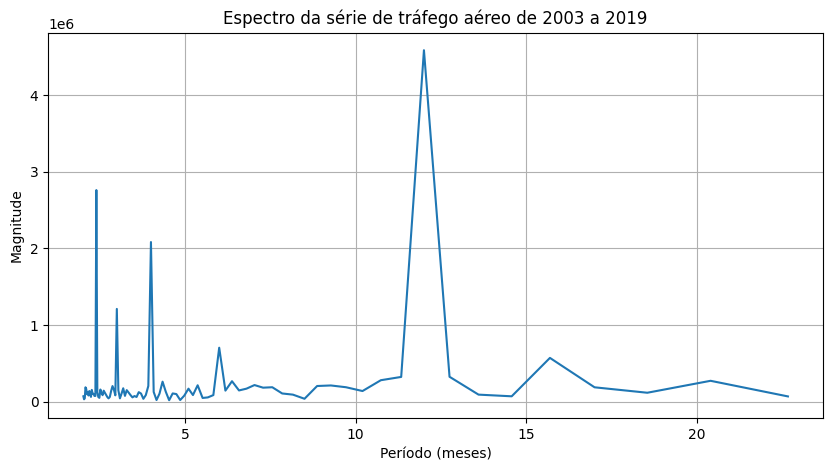

In [ ]:
# FFT somente de 2003 até 2019

# Seleciona os dados até dezembro de 2019
idx_2019 = df["Year"].to_numpy() <= 2019

voos_2019 = voos[idx_2019]
voos_2019 = voos_2019 - np.mean(voos_2019)

N_2019 = len(voos_2019)

# FFT
fft_2019 = np.fft.fft(voos_2019)

# Frequências
frequencias_2019 = np.fft.fftfreq(
    N_2019,
    d=1
)

# Magnitude
magnitude_2019 = np.abs(fft_2019)

# Apenas frequências positivas
idx = frequencias_2019 > 0

frequencias_2019 = frequencias_2019[idx]
magnitude_2019 = magnitude_2019[idx]

# Converter para período
periodos_2019 = 1 / frequencias_2019

# Considerar períodos até 25 meses
idx_periodo = periodos_2019 <= 25

plt.figure(figsize=(10, 5))

plt.plot(periodos_2019[idx_periodo], magnitude_2019[idx_periodo])

plt.title("Espectro da série de tráfego aéreo de 2003 a 2019")
plt.xlabel("Período (meses)")
plt.ylabel("Magnitude")
plt.grid(True)

plt.show()

## Conclusão da Análise pela FFT
A partir da análise do espctro tranformado pela FFT, é possível observar um pico de magnitude da sazonalidade por volta de 12 meses. Isto serve para evidenciar que o espectro temporal possui período de aproximadamente 12 meses, o que faz sentido quando se considera o valor do lag(K), o qual alcança uma significativa melhora quando passa de 12 para 13, alcançando seu valor mínimo de RMSE em 14. Desta forma, a conjectura de que o valor ótimo de K está relacionado com o período em que o espectro se repete ganha mais força.